<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install nltk -q

In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving nlp_dataset.csv to nlp_dataset.csv


In [4]:
df = pd.read_csv("nlp_dataset.csv")
df

,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear
...,...,...
5932,i begun to feel distressed for you,fear
5933,i left feeling annoyed and angry thinking that...,anger
5934,i were to ever get married i d have everything...,joy
5935,i feel reluctant in applying there because i w...,fear


In [6]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
print("Dataset Shape:", df.shape)
print("\nFirst Five Rows")
print(df.head())

Dataset Shape: (5937, 2)

First Five Rows
                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


In [8]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    return " ".join(words)

df['Processed_Text'] = df['Comment'].apply(preprocess)

print("\nProcessed Text")
print(df[['Comment','Processed_Text']].head())


Processed Text
                                             Comment  \
0  i seriously hate one subject to death but now ...   
1                 im so full of life i feel appalled   
2  i sit here to write i start to dig out my feel...   
3  ive been really angry with r and i feel like a...   
4  i feel suspicious if there is no one outside l...   

                                      Processed_Text  
0  seriously hate one subject death feel reluctan...  
1                         im full life feel appalled  
2  sit write start dig feelings think afraid acce...  
3  ive really angry r feel like idiot trusting fi...  
4  feel suspicious one outside like rapture happe...  


In [9]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['Processed_Text'])

y = df['Emotion']

print("\nFeature Matrix Shape:", X.shape)


Feature Matrix Shape: (5937, 5000)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("\n==============================")
print("Naive Bayes Results")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print("\nClassification Report")
print(classification_report(y_test, nb_pred))


Naive Bayes Results
Accuracy: 0.9090909090909091

Classification Report
              precision    recall  f1-score   support

       anger       0.88      0.95      0.91       392
        fear       0.91      0.92      0.92       416
         joy       0.94      0.86      0.90       380

    accuracy                           0.91      1188
   macro avg       0.91      0.91      0.91      1188
weighted avg       0.91      0.91      0.91      1188



In [12]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("\n==============================")
print("Support Vector Machine Results")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("\nClassification Report")
print(classification_report(y_test, svm_pred))



Support Vector Machine Results
Accuracy: 0.952020202020202

Classification Report
              precision    recall  f1-score   support

       anger       0.94      0.96      0.95       392
        fear       0.97      0.93      0.95       416
         joy       0.95      0.97      0.96       380

    accuracy                           0.95      1188
   macro avg       0.95      0.95      0.95      1188
weighted avg       0.95      0.95      0.95      1188



In [13]:
nb_accuracy = accuracy_score(y_test, nb_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

comparison = pd.DataFrame({
    "Model":["Naive Bayes","Support Vector Machine"],
    "Accuracy":[nb_accuracy, svm_accuracy]
})

print("\nModel Comparison")
print(comparison)


Model Comparison
                    Model  Accuracy
0             Naive Bayes  0.909091
1  Support Vector Machine  0.952020


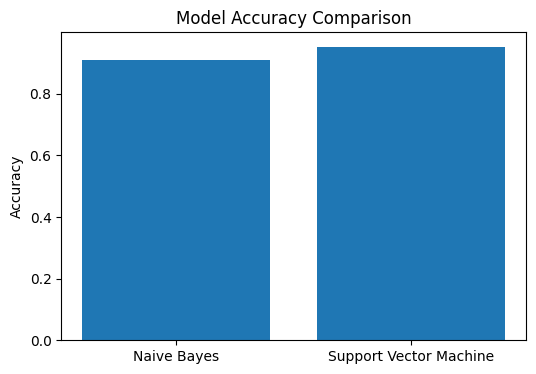

In [14]:
plt.figure(figsize=(6,4))
plt.bar(comparison["Model"], comparison["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

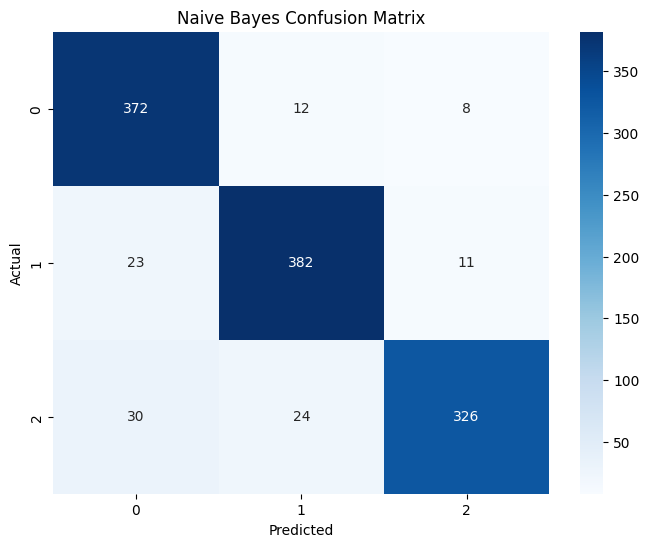

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, nb_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


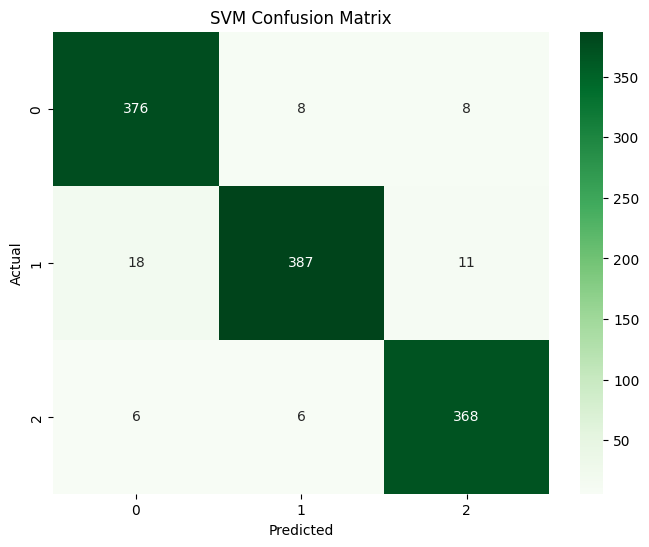

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, svm_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
if svm_accuracy > nb_accuracy:
    print("\nBest Model : Support Vector Machine")
else:
    print("\nBest Model : Naive Bayes")


Best Model : Support Vector Machine
